# Understanding swizzling

TLDR: the goals of this notebook are the following:
- To swizzle the A shared memory array focusing on **each warp** (i.e., dimension = `[WM x BK]`)
    - The shared memory array is divided into WMMA tiles where each tile has a dimension of `[MMA_M x MMA_K]`
        - There are `WM / MMA_M` number of WMMA tiles vertically
        - There are `BK / MMA_K` number of WMMA tiles horizontally
        - We don't want to swizzle the columns *within* each tile, which means that the `MMA_K` elements are not permuted
- To visualize the swizzled shared memory array

## Imports, classes, functions

In [14]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [15]:
# The following code taken and modified from https://github.com/NVIDIA/cutlass/blob/main/python/pycute/swizzle.py.

def shiftr(a, s):
  return a >> s if s > 0 else shiftl(a, -s)


def shiftl(a, s):
  return a << s if s > 0 else shiftr(a, -s)


class Swizzle:
    """Performs swizzling operations given the parameters bits_num, constant_lsb_num, and shift.

        Given the following operation example:
            i = i ^ ((i & 111000000) >> 3)

        - i indicates the offset or the index to be transformed
        - 111000000 is the yyy_mask
            - the number of zeroes comes from (constant_lsb_num + max(0, shift)) where
                - constant_lsb_num indicates the number of least-significant bits to keep constant
                - shift indicates the distance to shift
            - `111` comes from (1 << bits_num) - 1
        - 3 from `>> 3` is the number to shift
    """
    def __init__(self, bits_num, constant_lsb_num, shift):
        assert bits_num >= 0
        assert constant_lsb_num >= 0
        assert abs(shift) >= bits_num
        self.bits_num = bits_num
        self.constant_lsb_num = constant_lsb_num
        self.shift = shift
        bit_mask = (1 << bits_num) - 1
        self.yyy_mask = bit_mask << (constant_lsb_num + max(0,shift))

    # operator ()    (transform integer)
    def __call__(self, offset):
        return offset ^ shiftr(offset & self.yyy_mask, self.shift)

In [23]:
def plot_shared_memory(
    smem_bank_array: np.ndarray,
    annotate_array: np.ndarray,
    WM: int,
    BK: int,
    MMA_M: int,
    MMA_K: int,
    NUM_MMA_ROWS: int,
    NUM_MMA_COLS: int,
    title: str = "",
):
    smem_bank_array = smem_bank_array.astype(int)
    annotate_array  = annotate_array.astype(int)

    _, ax = plt.subplots(figsize=(10, 20))
    ax.imshow(smem_bank_array, cmap="tab20")
    ax.set_xticks(np.arange(BK)-0.5, minor=True)
    ax.set_yticks(np.arange(WM)-0.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=1.5)

    # Add bank annotations.
    for i in range(smem_bank_array.shape[0]):
        for j in range(smem_bank_array.shape[1]):
            ax.text(j, i, annotate_array[i, j], ha="center", va="center", color="w", size="small")

    for row_idx in range(1, NUM_MMA_ROWS):
        ax.axhline(y=(MMA_M * row_idx) - 0.5, color="black", linestyle='--', linewidth=2)

    for col_idx in range(1, NUM_MMA_COLS):
        ax.axvline(x=(MMA_K * col_idx) - 0.5, color="black", linestyle='--', linewidth=2)

    plt.title(title) 
    plt.tight_layout()
    plt.show()

## Introduction

This notebook aims to visualize the results of using [cutlass's swizzle](https://github.com/NVIDIA/cutlass/blob/main/python/pycute/swizzle.py) parameters `base`, `shift`, and `bits` in the context of warp-based matrix multiplication (WMMA).

We'll look into swizzling shared memory that stores elements of **matrix A**. The shared memory has a dimension of `[BM x BK]` where `BM` indicates the number of rows in a thread-block and `BK` indicates the number of columns in each tile that slides across `K`. For simplicity, instead of the thread-block level, we'll focus on the **warp-level** instead. This entails the following:

- The number of rows is now `WM`, which indicates the number of rows in each warp
- The number of columns remains `BK` since we don't define `WK`; this makes it simpler when dividing the shared memory array into WMMA tiles, i.e., the number of WMMA tiles horizontally is simply `BK / WK`

Recall that the shared memory is divided into 32 banks, each slot storing 4 bytes of data. This means that our `[WM x BK]` values with 2 bytes each are stored with the following layout.

```
|    bank 0     |    bank 1     |    bank 2     | ... |    bank 29    |    bank 30    |    bank 31    |
|-----------------------------------------------------------------------------------------------------|
| val_00,val_01 | val_02,val_03 | val_04,val_05 | ... | val_58,val_59 | val_60,val_61 | val_62,val_63 |
| val_64,val_65 | val_66,val_67 | val_68,val_69 | ... | <and so on>
```

As an example, let's say we have the following parameters.

```
WM    = 64,    BK = 16
MMA_M = 16, MMA_K = 8
```

We then have `[64 x 16]` values. Let's try to visualize shared memory array with the bank division in our first exercise.

In [4]:
# Initialize parameters.
WM = 64 # number of rows in A shared memory.
BK = 16 # number of columns in A shared memory.

MMA_M = 16
MMA_K = 8

assert(WM % MMA_M == 0)
assert(BK % MMA_K == 0)

NUM_MMA_COLS = int(BK / MMA_K)
NUM_MMA_ROWS = int(WM / MMA_M)

In [18]:
# Initialize the shared memory, we'll use ordered integers for visualization purposes.
As = np.arange(WM * BK).reshape((WM, BK))
As

array([[   0,    1,    2, ...,   13,   14,   15],
       [  16,   17,   18, ...,   29,   30,   31],
       [  32,   33,   34, ...,   45,   46,   47],
       ...,
       [ 976,  977,  978, ...,  989,  990,  991],
       [ 992,  993,  994, ..., 1005, 1006, 1007],
       [1008, 1009, 1010, ..., 1021, 1022, 1023]], shape=(64, 16))

In [19]:
# Divide shared memory into banks.
# Each bank stores 2x2-byte elements, so 32 banks store 64 2-byte elements.
As_by_bank = (As % 64) // 2
As_by_bank

array([[ 0,  0,  1, ...,  6,  7,  7],
       [ 8,  8,  9, ..., 14, 15, 15],
       [16, 16, 17, ..., 22, 23, 23],
       ...,
       [ 8,  8,  9, ..., 14, 15, 15],
       [16, 16, 17, ..., 22, 23, 23],
       [24, 24, 25, ..., 30, 31, 31]], shape=(64, 16))

In [21]:
# Both element 0 and 64 should all be stored in bank 0.
assert(As_by_bank[0, 0] == 0)
assert(As_by_bank[4, 0] == 0)

In [8]:
As_by_bank

array([[ 0,  0,  1, ...,  6,  7,  7],
       [ 8,  8,  9, ..., 14, 15, 15],
       [16, 16, 17, ..., 22, 23, 23],
       ...,
       [ 8,  8,  9, ..., 14, 15, 15],
       [16, 16, 17, ..., 22, 23, 23],
       [24, 24, 25, ..., 30, 31, 31]], shape=(64, 16))

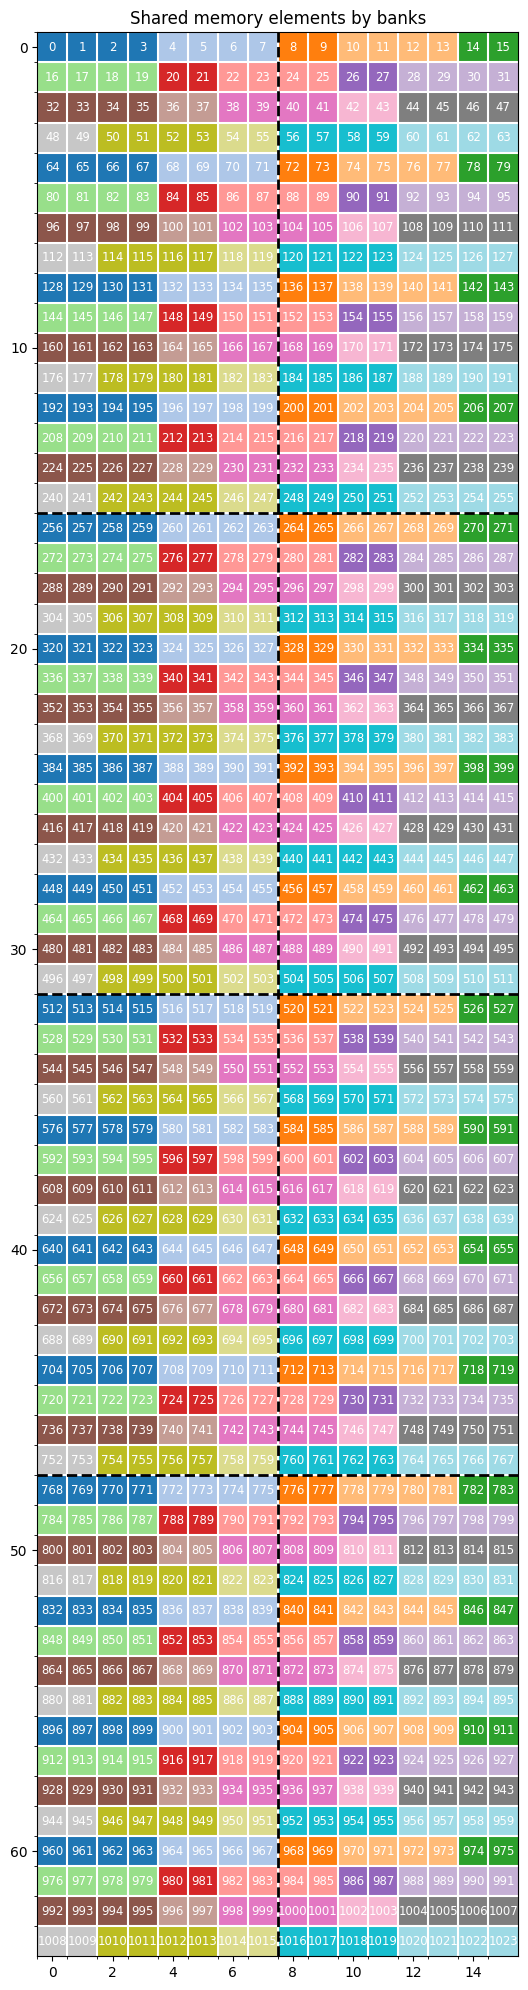

In [ ]:
# Visualize the elements in As colored by banks.
plot_shared_memory(
    As_by_bank, As, WM, BK, MMA_M, MMA_K, NUM_MMA_ROWS, NUM_MMA_COLS, title="Shared memory elements by banks")

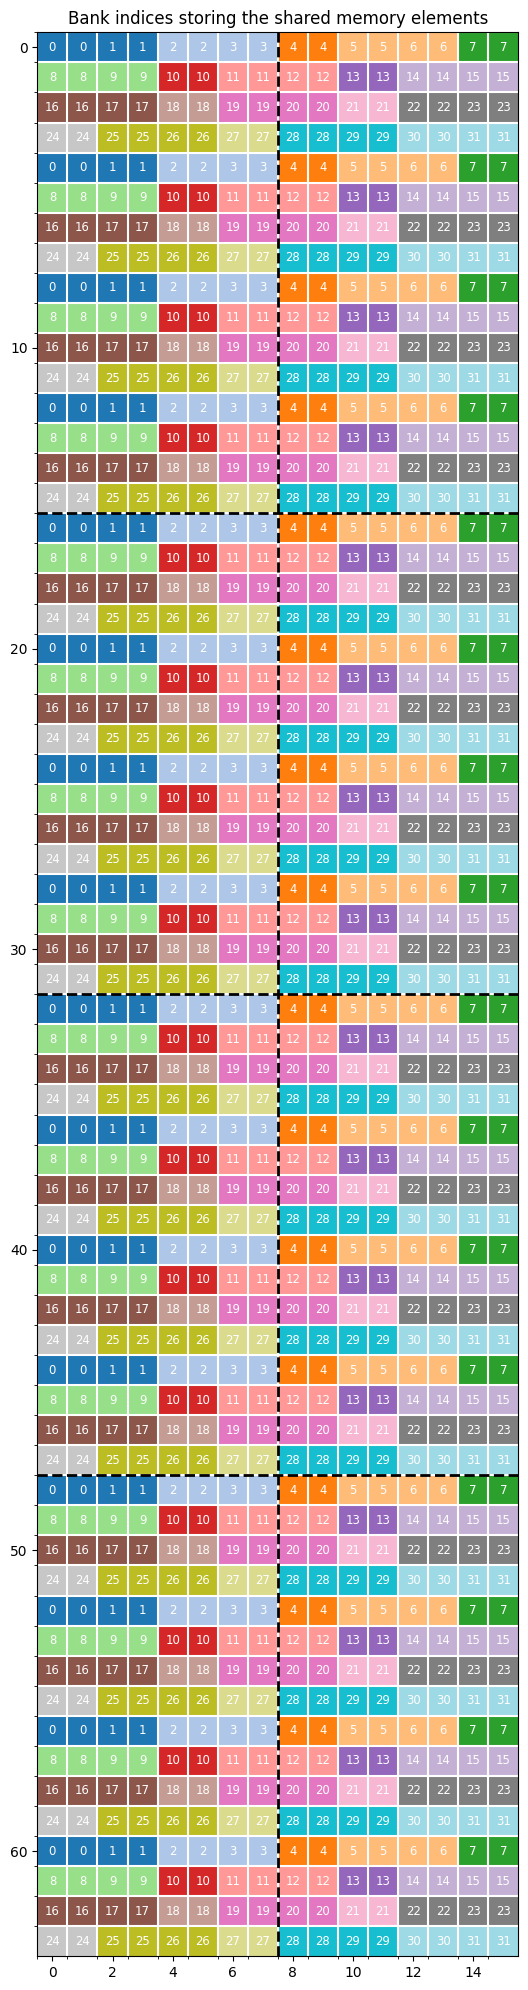

In [ ]:
# Visualize the bank indices storing the elements.
plot_shared_memory(
    As_by_bank, As_by_bank, WM, BK, MMA_M, MMA_K, NUM_MMA_ROWS, NUM_MMA_COLS, title="Bank indices storing the shared memory elements")

Based on the visualizations above, we can see that each WMMA tile (loaded by the threads in a warp) hits the same bank 4 times, causing 4-way conflicts. One may think that it's actually an 8-way conflict issue, but since 2 elements are stored in one bank, [accesses to the different 2 elements that are of a consecutive 4 bytes stored in the same bank are considered as broadcasting](https://stackoverflow.com/questions/48501489/should-cuda-shared-memory-arrays-with-type-sizes-of-less-than-4-8-bytes-per-elem).

## Performing swizzling

In [29]:
def perform_swizzle(swizzle_op: Swizzle, As: np.ndarray) -> np.ndarray:
    """Performs swizzle on As and returns the updated banks."""
    swizzled_As_by_bank = np.zeros((WM, BK)).astype(int)

    for row_idx in range(WM):
        for col_idx in range(BK):
            swizzled_value = swizzle_op(As[row_idx, col_idx])
            # Double-check that the rows don't change.
            assert(
                (swizzled_value // 64) == (As[row_idx, col_idx] // 64),
                f'Rows have changed: element {As[row_idx, col_idx]} now has index {swizzled_value}.')
            swizzled_As_by_bank[row_idx, col_idx] = int((swizzled_value % 64) // 2)

    return swizzled_As_by_bank

In [30]:
# To recall, we want to keep constant the columns within the WMMA tile.
constant_lsb_num = int(np.log2(MMA_K))

# Feel free to play around with the values below.
bits_num         = 3
shift            = 4
print(constant_lsb_num, bits_num, shift)

# Create the swizzle_op object.
swizzle_op = Swizzle(bits_num, constant_lsb_num, shift)

3 3 4


In [31]:
swizzled_As_by_bank = perform_swizzle(swizzle_op, As)

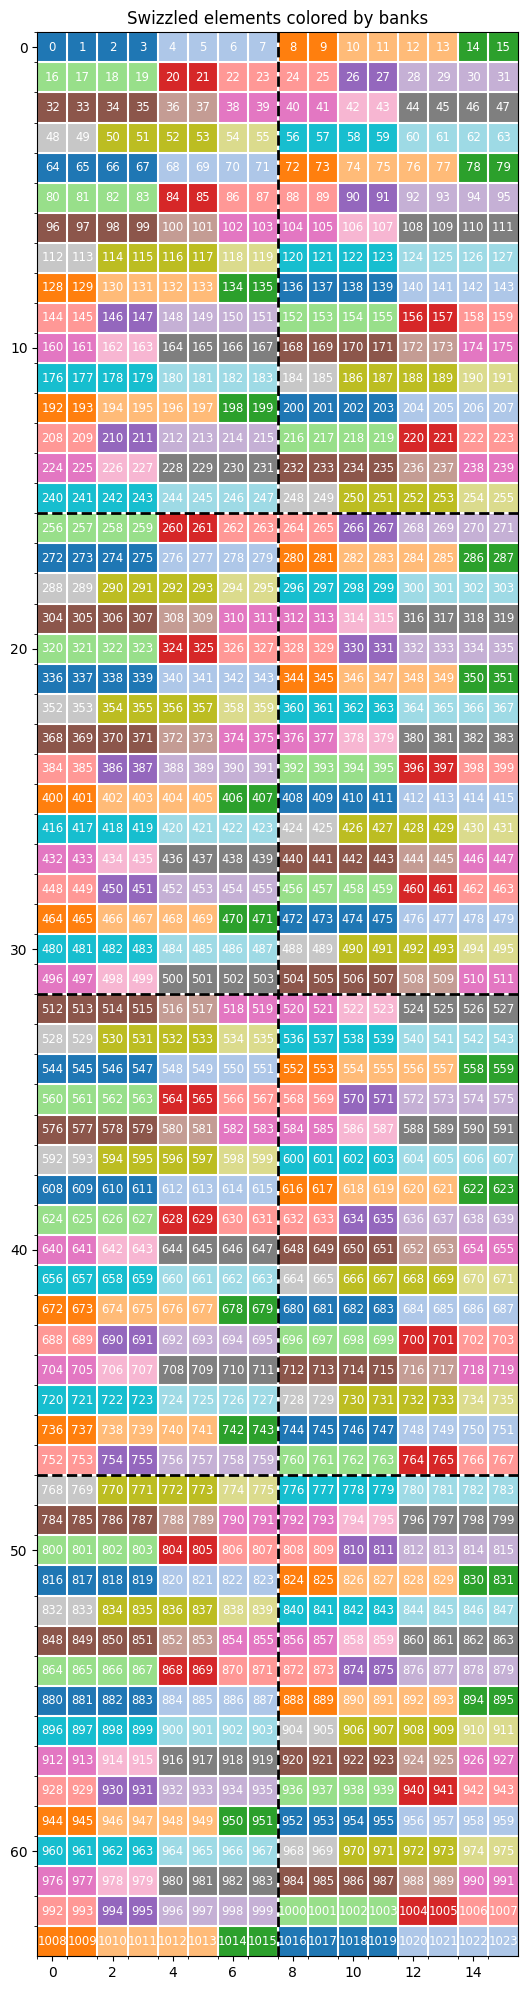

In [33]:
plot_shared_memory(
    swizzled_As_by_bank, As, WM, BK, MMA_M, MMA_K, NUM_MMA_ROWS, NUM_MMA_COLS, title="Swizzled elements colored by banks")


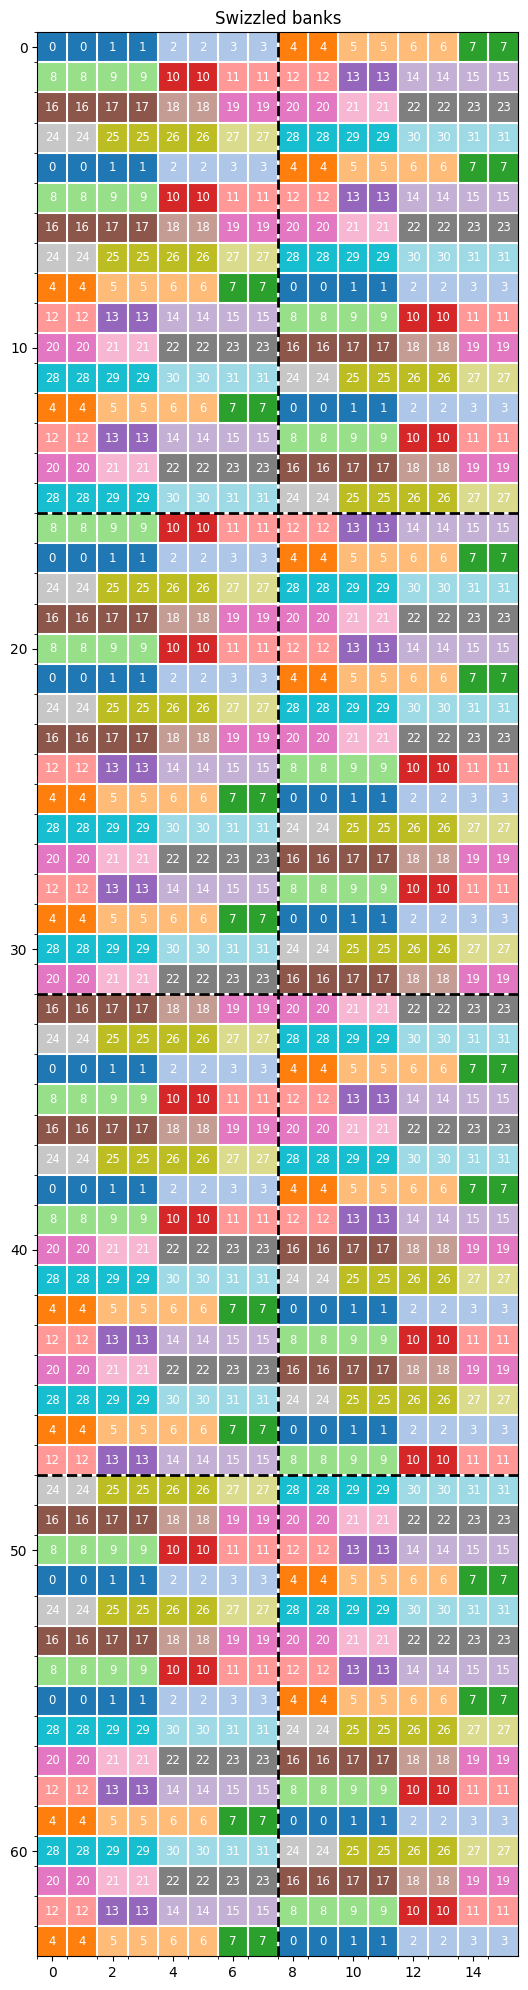

In [35]:
plot_shared_memory(swizzled_As_by_bank, swizzled_As_by_bank, WM, BK, MMA_M, MMA_K, NUM_MMA_ROWS, NUM_MMA_COLS, title="Swizzled banks")

Using parameters `Swizzle(3, 3, 4)` now results in 2-way bank conflicts, a much better state than the initial 4-way bank conflicts. Note that having at least 2-way bank conflicts is inevitable given that each warp in the example loads 64 x 4 bytes different elements and there are only 32 banks to store them.